In [38]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, f1_score
)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay

!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

In [ ]:
# A) Introduction & Data Source
# Upload data
df = pd.read_csv('airline_passenger_satisfaction_with_missing.csv')
df.head()

In [ ]:
# Basic information
print("Shape (rows, columns):", df.shape)

In [ ]:
#Data Information
df.info()

In [ ]:
# The distribution of the response variable
df['Satisfaction'].value_counts(dropna=False)


In [ ]:
#Summary statistics for numerical variables
df.describe()

In [ ]:
#Identify candidate categorical and numerical variables
# All columns
all_cols = df.columns.tolist()

# Pre-define target and ID
target_col = "Satisfaction"
id_col = "ID"

# Treat everything that is 'object' as categorical
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Remove target from the list if you want "predictors only"
categorical_predictors = [c for c in categorical_cols if c != target_col]

# Numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_predictors = [c for c in numeric_cols if c != id_col]

print("ID column:", id_col)
print("Target (dependent) variable:", target_col)
print("Categorical predictors:", categorical_predictors)
print("Numeric predictors:", numeric_predictors)


In [ ]:
#Basic frequency tables for key categorical variables
cat_vars_to_check = [
    "Gender",
    "Customer Type",
    "Type of Travel",
    "Class",
    "Satisfaction"
]

for col in cat_vars_to_check:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))


In [ ]:
# Quick check of missing values per variable
missing_per_col = df.isna().sum().sort_values(ascending=False)
missing_percent_per_col = df.isna().mean().sort_values(ascending=False) * 100

missing_summary = pd.concat(
    [missing_per_col.rename("MissingCount"),
     missing_percent_per_col.round(2).rename("MissingPercent")],
    axis=1
)

missing_summary


In [39]:
# Overall missingness in the dataset
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isna().sum().sum()
overall_missing_rate = 100 * total_missing / total_cells

print(f"Total missing entries      : {total_missing}")
print(f"Overall missingness (%)    : {overall_missing_rate:.2f}")


Total missing entries      : 170601
Overall missingness (%)    : 5.25


In [40]:
# B) Data Cleaning & Preprocessing
# Remove duplicate rows
n_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", n_duplicates)

df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Number of duplicate rows: 0
Shape after removing duplicates: (129880, 25)


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer

In [36]:
# B) DATA CLEANING & PREPROCESSING

# 2. DATA TIDYING

# 2.1 Remove duplicate rows
df = df.drop_duplicates()

# 2.2 Clean categorical columns (trim extra spaces)
cat_cols_raw = ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Satisfaction']

for col in cat_cols_raw:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# 2.3 Fix invalid numeric values

# Delays cannot be negative
for col in ['Departure Delay', 'Arrival Delay']:
    if col in df.columns:
        df[col] = df[col].clip(lower=0)

# Age must be between 0 and 100; otherwise set to NaN
if 'Age' in df.columns:
    df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = np.nan

print("\nDataset shape after tidying:", df.shape)

# 3. MISSING VALUE ANALYSIS

missing_table = df.isna().sum()
missing_percent = 100 * missing_table / len(df)

missing_summary = pd.DataFrame({
    "Missing Count": missing_table,
    "Missing Percentage": missing_percent
})

print("\n=== Missing Value Summary (sorted by % missing) ===\n")
print(missing_summary.sort_values(by="Missing Percentage", ascending=False))

# 4. MISSINGNESS MECHANISM CHECK (MCAR vs MAR)
#    Example variable: 'In-flight Wifi Service'

if 'In-flight Wifi Service' in df.columns:
    # 4.0 Create missingness indicator
    df["MISS_Wifi"] = df['In-flight Wifi Service'].isna().astype(int)

    # 4.1 Chi-square test between missingness and Class (categorical)
    if 'Class' in df.columns:
        ct = pd.crosstab(df["MISS_Wifi"], df["Class"])
        chi2, p_chi, _, _ = stats.chi2_contingency(ct)
        print("\nChi-square test p-value (MISS_Wifi vs Class):", p_chi)

    # 4.2 t-test between missingness and Flight Distance (numeric)
    if 'Flight Distance' in df.columns:
        group1 = df.loc[df["MISS_Wifi"] == 1, "Flight Distance"].dropna()
        group2 = df.loc[df["MISS_Wifi"] == 0, "Flight Distance"].dropna()

        if len(group1) > 0 and len(group2) > 0:
            t_stat, p_ttest = stats.ttest_ind(group1, group2, equal_var=False)
            print("T-test p-value (MISS_Wifi vs Flight Distance):", p_ttest)

    # Interpretation comment (for your report):
    # If either p_chi or p_ttest < 0.05 -> missingness is related to other variables,
    # therefore NOT MCAR (likely MAR). If all tests are clearly non-significant,
    # MCAR is more plausible. MNAR cannot be proven from observed data.

# 5. IMPUTATION (MISSING VALUE CLEANING)
#    We will create TWO versions:
#    5.1 k-NN based
#    5.2 Model-based (Iterative / MICE)

# 5.0 Separate predictors and target
if "Satisfaction" not in df.columns:
    raise ValueError("Column 'Satisfaction' (target) not found in df.")

X = df.drop(columns=["Satisfaction"])
y = df["Satisfaction"]

# Identify numeric and categorical predictor columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Remove ID and missingness indicator from numeric modeling (if present)
for col in ["ID", "MISS_Wifi"]:
    if col in num_cols:
        num_cols.remove(col)

print("\nNumeric columns used for imputation:", num_cols)
print("Categorical columns used for imputation:", cat_cols)

# 5.1 k-NN IMPUTATION (numeric) + MODE (categorical)

num_imputer_knn = KNNImputer(n_neighbors=5)
cat_imputer = SimpleImputer(strategy="most_frequent")

preprocessor_knn = ColumnTransformer(
    transformers=[
        ("num", num_imputer_knn, num_cols),
        ("cat", cat_imputer, cat_cols)
    ],
    remainder="drop"
)

X_imputed_knn_array = preprocessor_knn.fit_transform(X)

# Build DataFrame with correct column order
X_imputed_knn = pd.DataFrame(
    X_imputed_knn_array,
    columns=num_cols + cat_cols
)

print("\n=== Dataset after k-NN + Mode Imputation (first 5 rows) ===")
print(X_imputed_knn.head())

# 5.2 MODEL-BASED IMPUTATION (Iterative / MICE)
#     - IterativeImputer for numeric variables
#     - Mode imputation for categorical variables

iter_imputer = IterativeImputer(random_state=42)

# Apply model-based imputer only on numeric columns
X_num_model_array = iter_imputer.fit_transform(X[num_cols])
X_num_model = pd.DataFrame(X_num_model_array, columns=num_cols)

# Categorical variables still imputed by most frequent category
cat_imputer_mb = SimpleImputer(strategy="most_frequent")
X_cat_model_array = cat_imputer_mb.fit_transform(X[cat_cols])
X_cat_model = pd.DataFrame(X_cat_model_array, columns=cat_cols)

# Combine numeric + categorical back into a single DataFrame
X_imputed_model = pd.concat([X_num_model, X_cat_model], axis=1)

print("\n=== Dataset after MODEL-BASED (Iterative) Imputation (first 5 rows) ===")
print(X_imputed_model.head())

# 6. FINAL CLEAN DATASETS FOR MODELING
#    We create TWO clean versions:
#      - k-NN version:   X_knn_clean,   y_clean
#      - Model-based:    X_model_clean, y_clean

# Remove rows where target y is missing
valid_idx = ~y.isna()

# k-NN based final dataset
X_knn_clean = X_imputed_knn.loc[valid_idx].reset_index(drop=True)
y_clean = y.loc[valid_idx].reset_index(drop=True)

# Model-based final dataset
X_model_clean = X_imputed_model.loc[valid_idx].reset_index(drop=True)
# y_clean is the same target

print("\nFinal Clean Dataset (k-NN) X shape:", X_knn_clean.shape)
print("Final Clean Dataset (model-based) X shape:", X_model_clean.shape)
print("Final Clean Target shape:", y_clean.shape)

# Final NA checks
print("\nRemaining NA in X_knn_clean:", X_knn_clean.isna().sum().sum())
print("Remaining NA in X_model_clean:", X_model_clean.isna().sum().sum())
print("Remaining NA in y_clean:", y_clean.isna().sum())



Dataset shape after tidying: (129880, 25)

=== Missing Value Summary (sorted by % missing) ===

                                        Missing Count  Missing Percentage
Arrival Delay                                    9177            7.065753
On-board Service                                 9107            7.011857
Gate Location                                    9074            6.986449
Departure and Arrival Time Convenience           9047            6.965661
In-flight Wifi Service                           9040            6.960271
Cleanliness                                      9032            6.954111
In-flight Entertainment                          9025            6.948722
Check-in Service                                 9003            6.931783
ID                                               8993            6.924084
Ease of Online Booking                           8984            6.917154
Departure Delay                                  8956            6.895596
Age            

Numeric columns: ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'MISS_Wifi']
Categorical columns: ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'Satisfaction']

=== Descriptive statistics for numeric variables ===
                                           count         mean         std  \
Age                                     120931.0    39.433991   15.121350   
Flight Distance                         120958.0  1190.808380  997.842466   
Departure Delay                         120924.0    14.731120   38.248864   
Arrival Delay                           120703.0    15.097761   38.397631   
Departure and Arrival Time Convenience  120833.0     3.056326    1.52

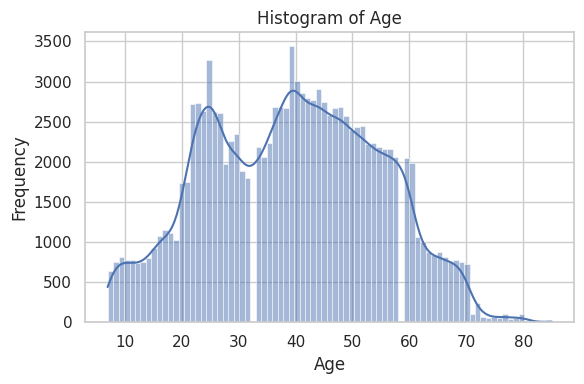

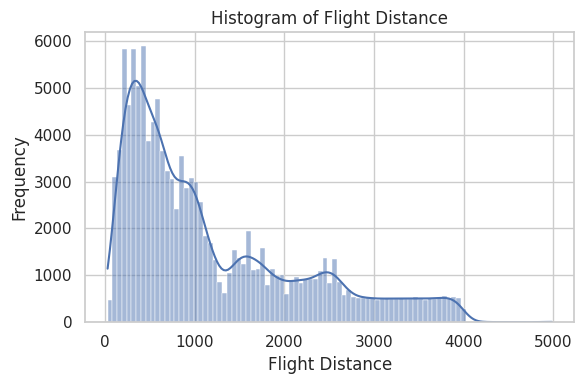

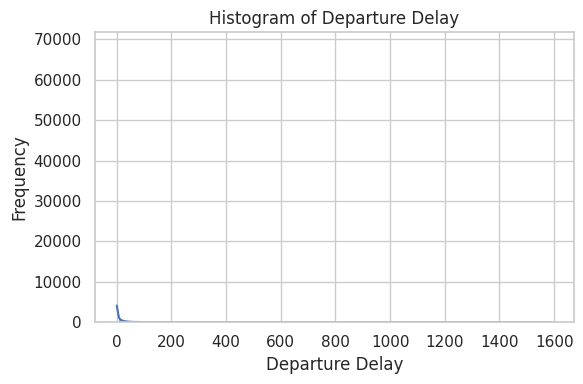

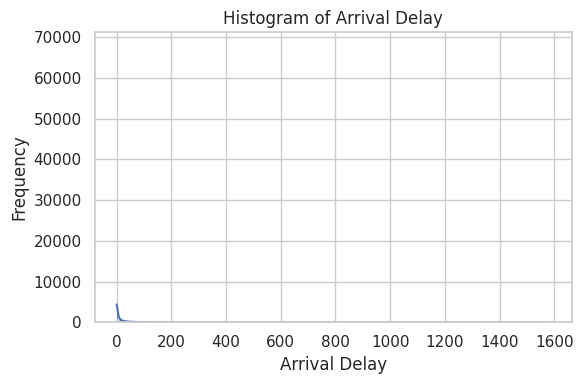

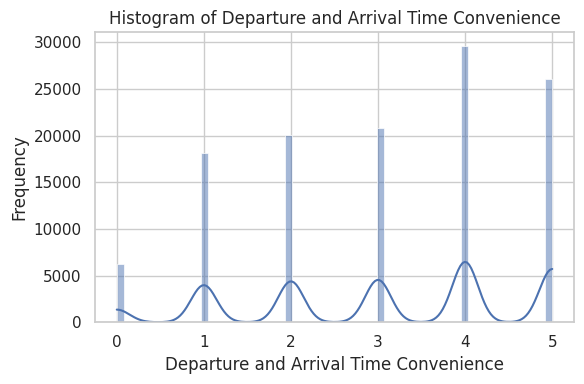

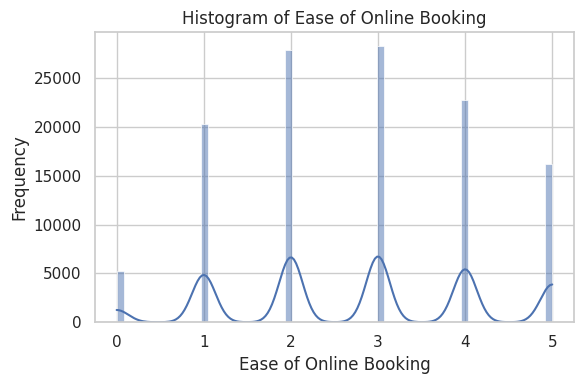

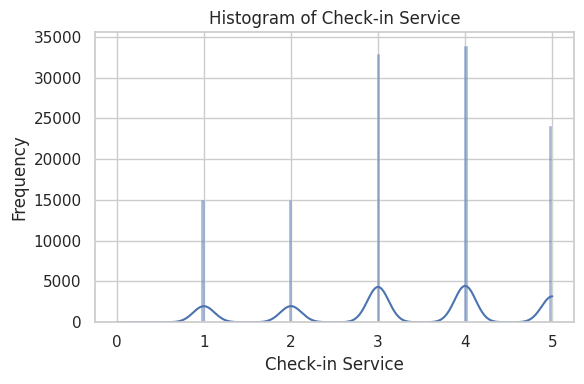

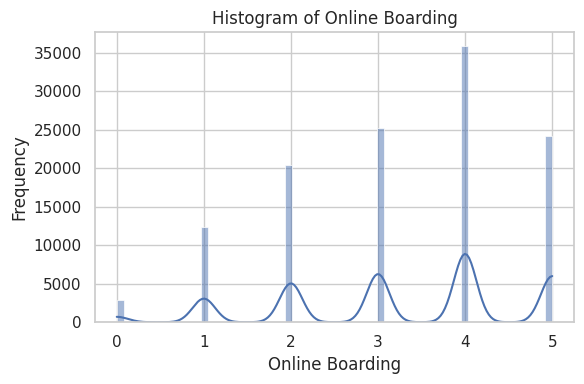

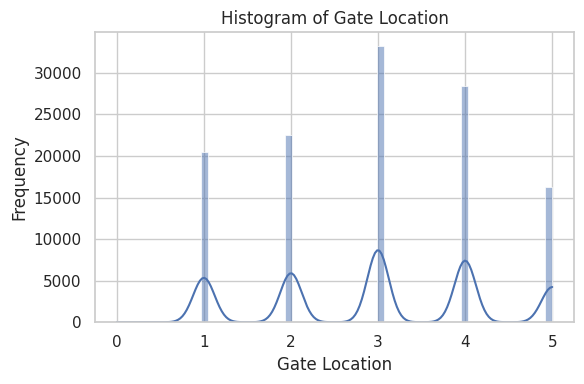

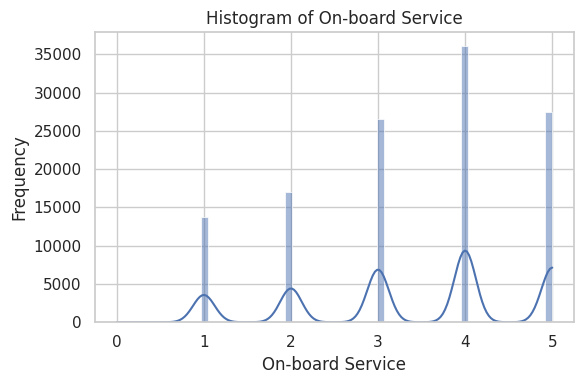

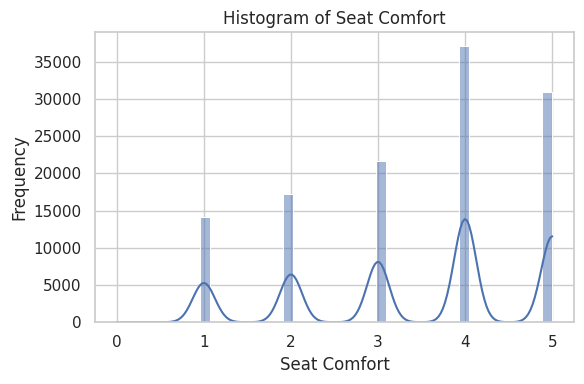

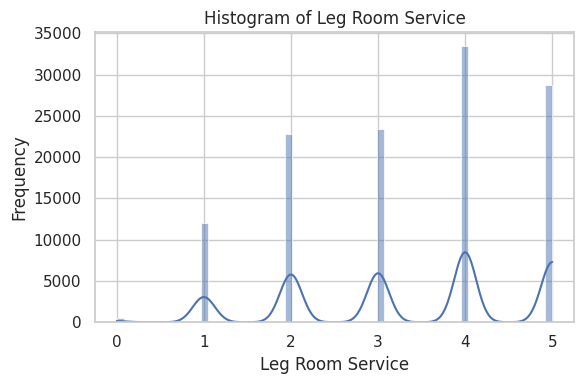

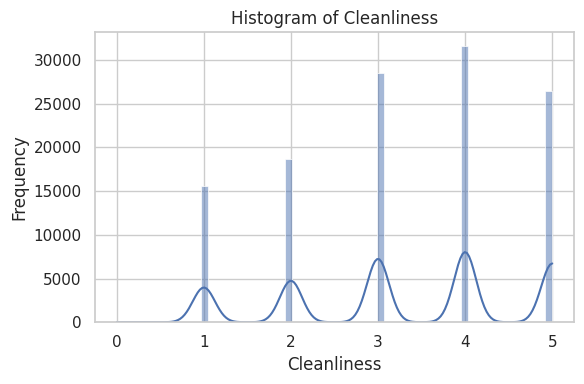

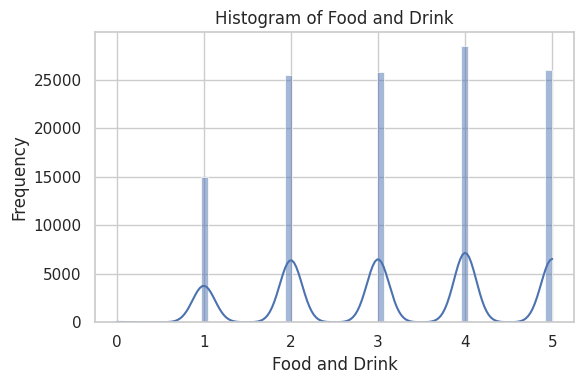

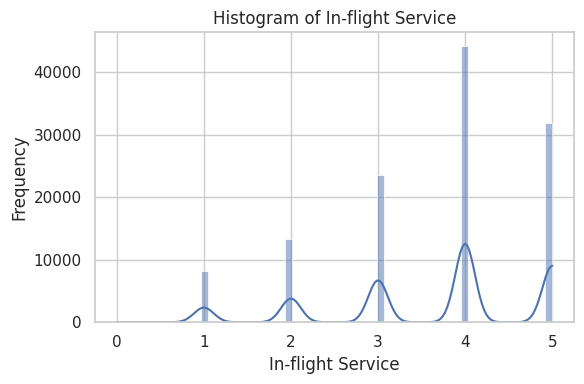

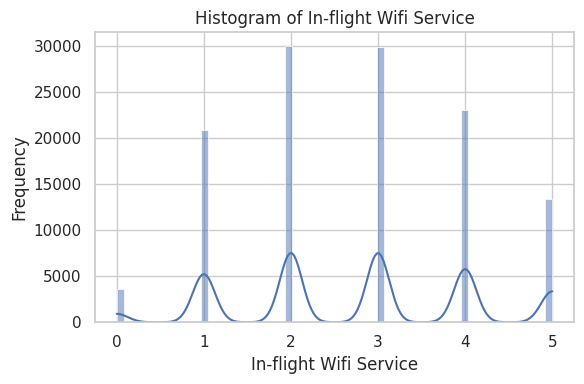

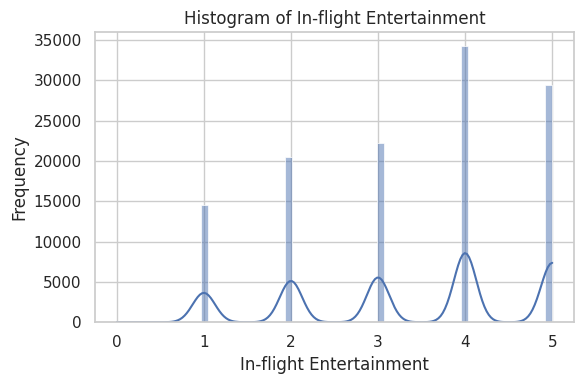

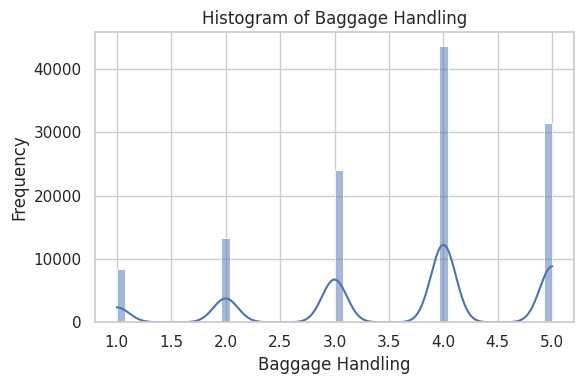

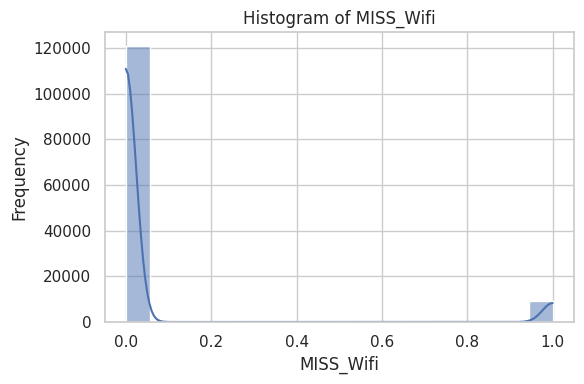

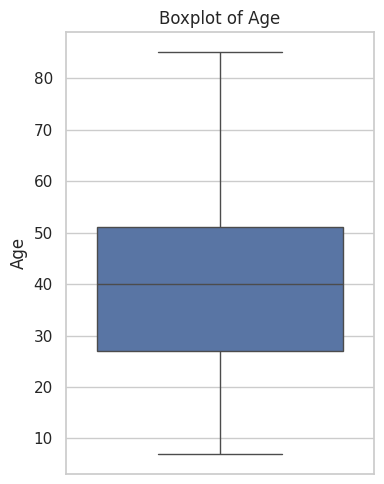

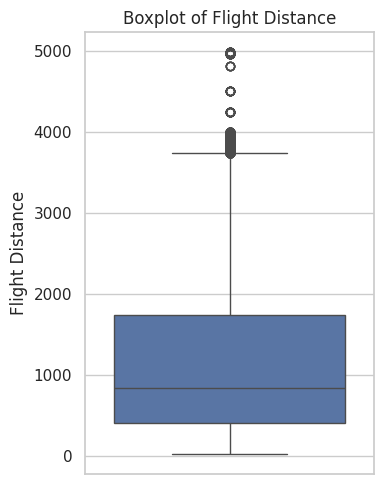

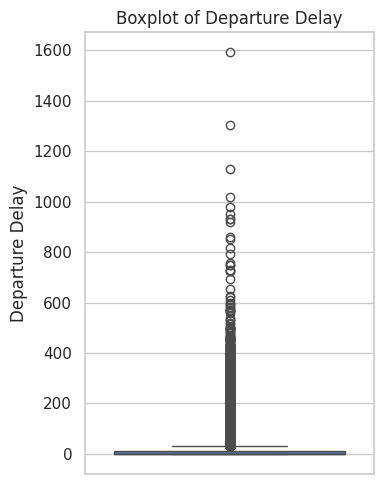

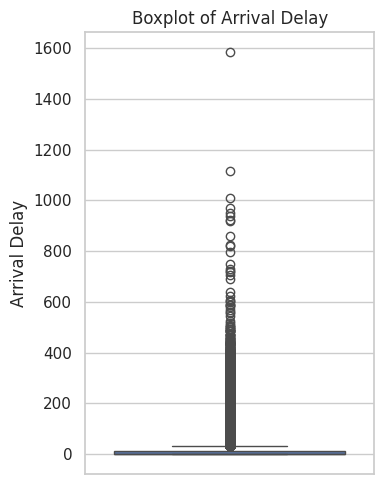

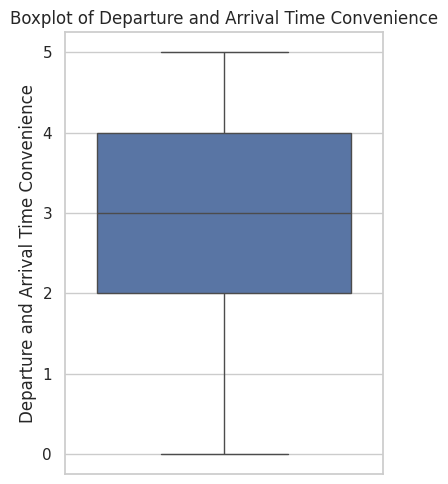

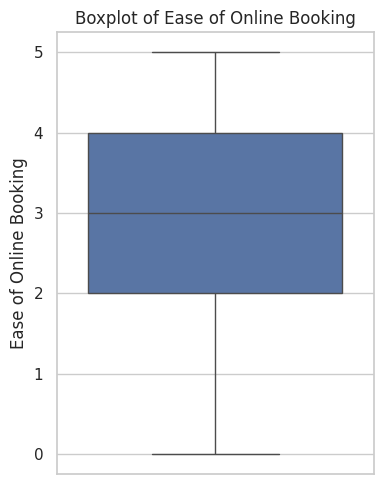

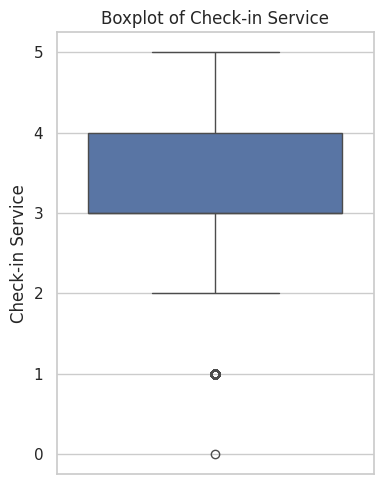

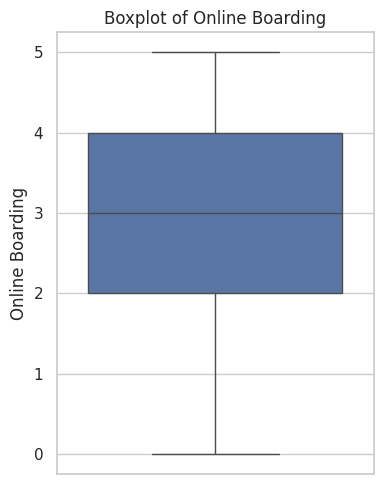

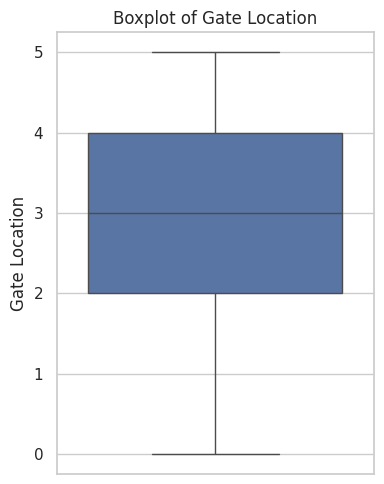

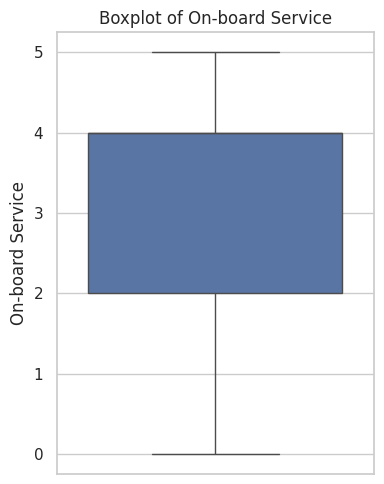

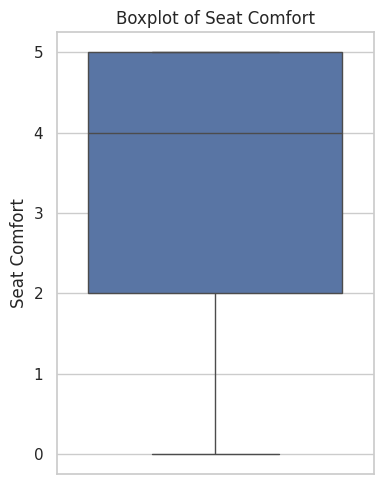

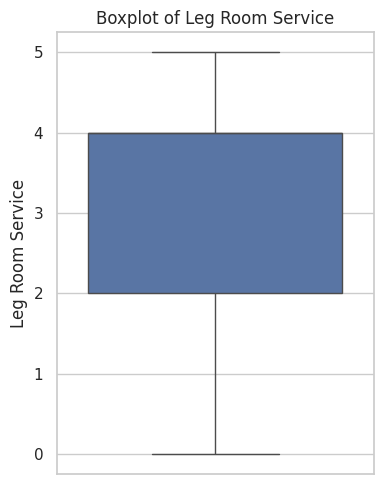

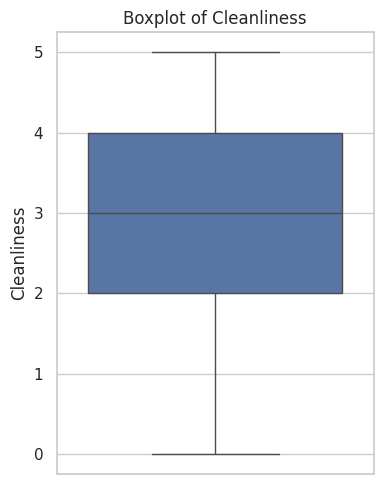

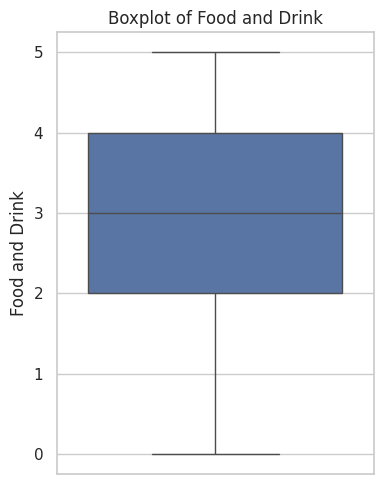

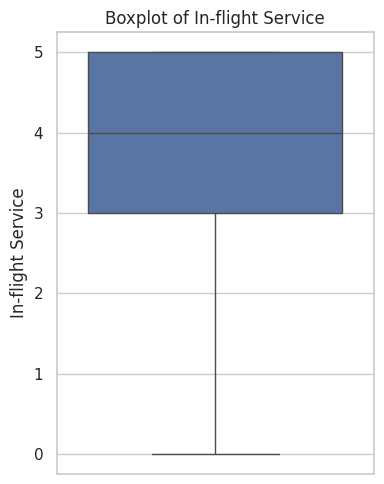

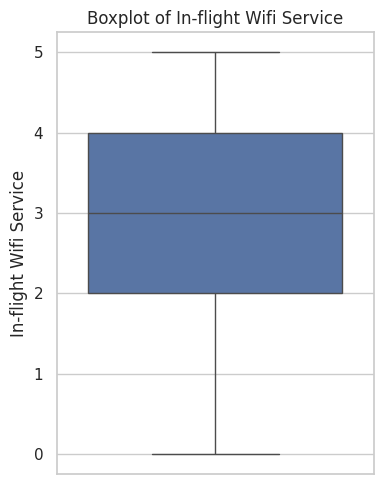

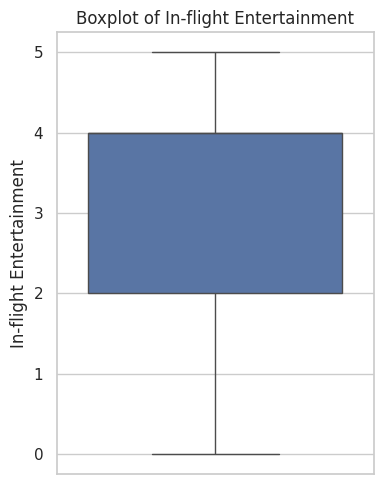

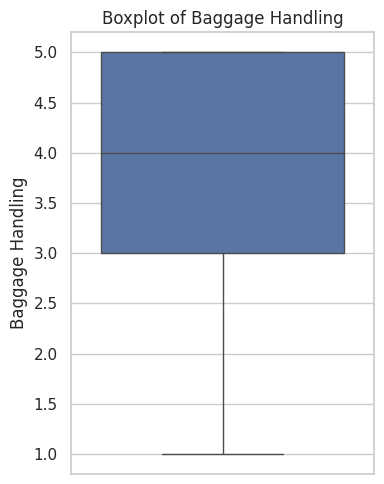

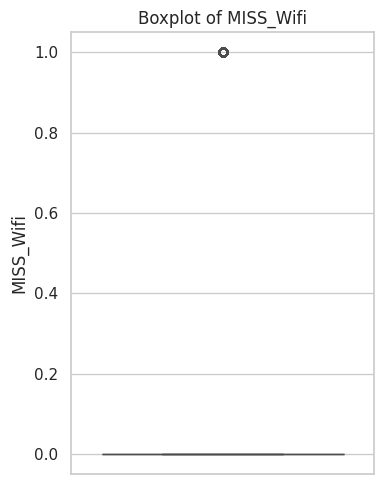


=== Frequency table for Gender ===
Gender
Female    61396
Male      59711
nan        8773
Name: count, dtype: int64


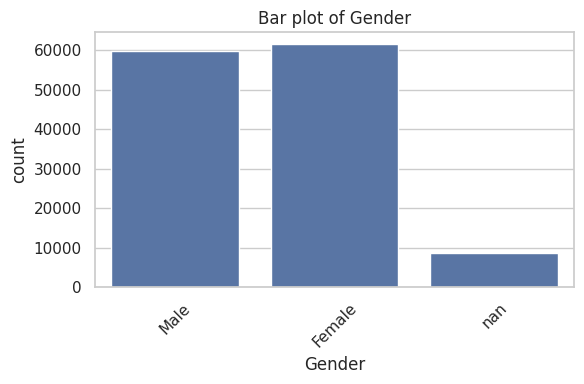


=== Frequency table for Customer Type ===
Customer Type
Returning     98812
First-time    22184
nan            8884
Name: count, dtype: int64


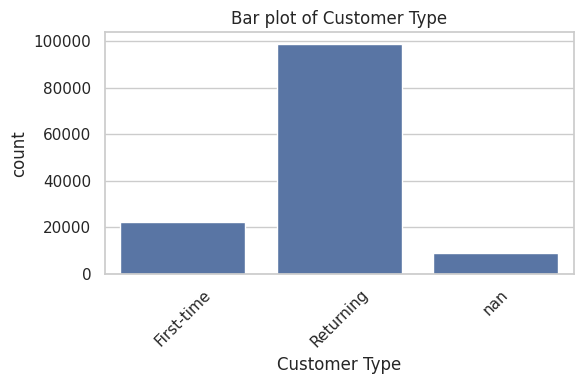


=== Frequency table for Type of Travel ===
Type of Travel
Business    83541
Personal    37498
nan          8841
Name: count, dtype: int64


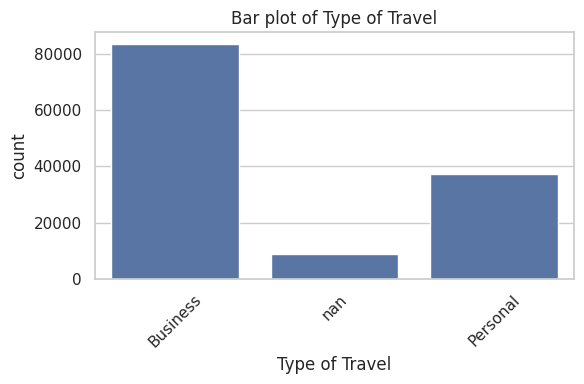


=== Frequency table for Class ===
Class
Business        57946
Economy         54391
Economy Plus     8786
nan              8757
Name: count, dtype: int64


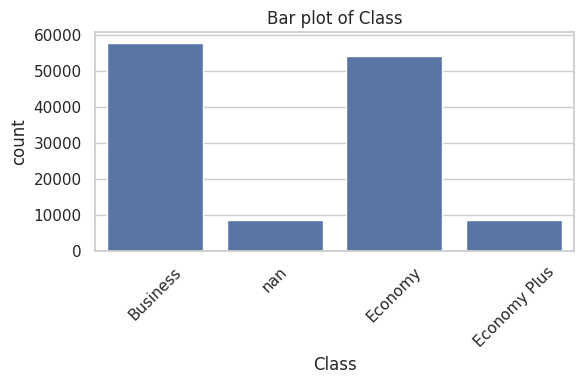


=== Frequency table for Satisfaction ===
Satisfaction
Neutral or Dissatisfied    68464
Satisfied                  52642
nan                         8774
Name: count, dtype: int64


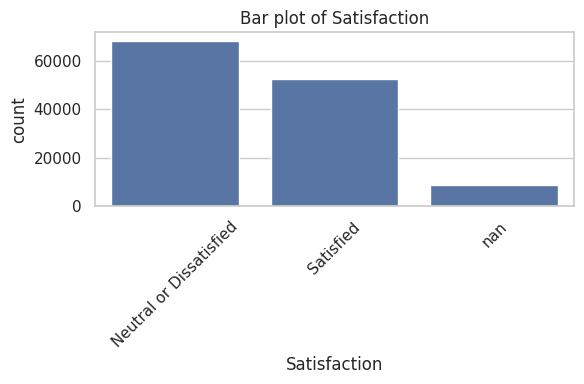


=== Correlation matrix (numeric variables) ===
                                             Age  Flight Distance  \
Age                                     1.000000         0.098492   
Flight Distance                         0.098492         1.000000   
Departure Delay                        -0.008885         0.001821   
Arrival Delay                          -0.010110        -0.003847   
Departure and Arrival Time Convenience  0.036364        -0.021106   
Ease of Online Booking                  0.022256         0.064231   
Check-in Service                        0.033749         0.072459   
Online Boarding                         0.208677         0.213547   
Gate Location                          -0.001093         0.005010   
On-board Service                        0.057218         0.112953   
Seat Comfort                            0.159837         0.156756   
Leg Room Service                        0.037599         0.135917   
Cleanliness                             0.051201       

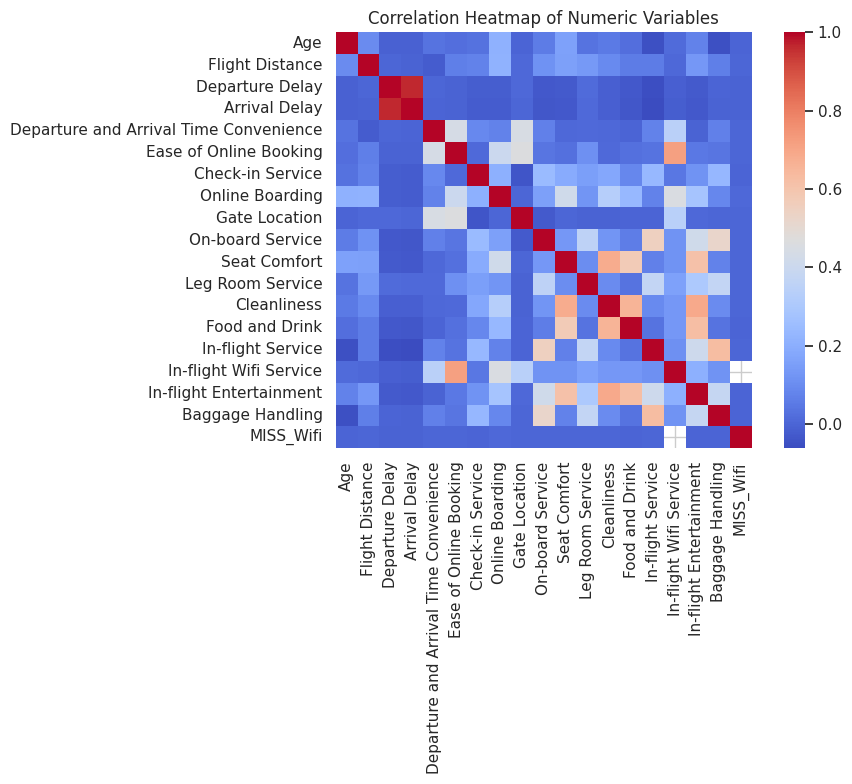

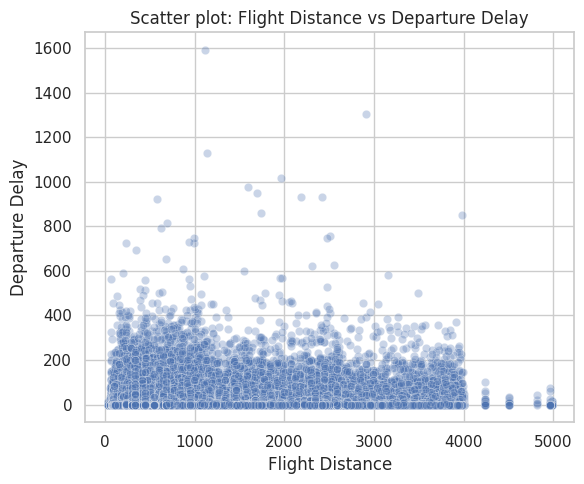

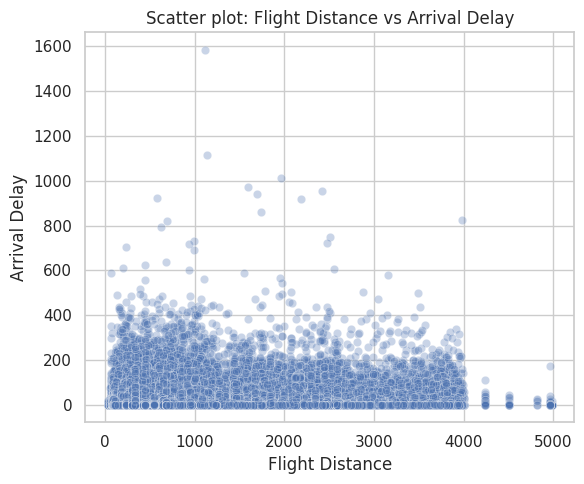

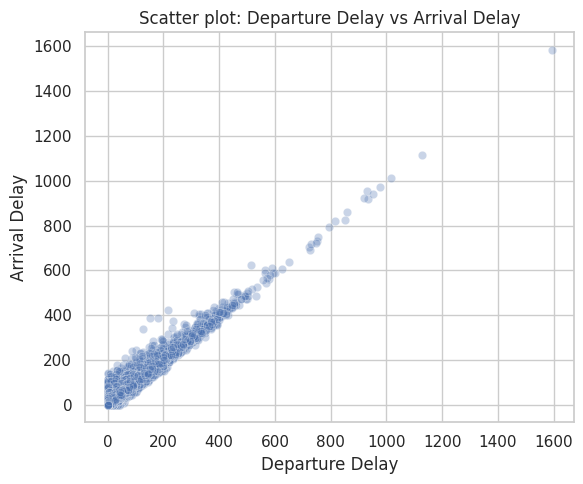

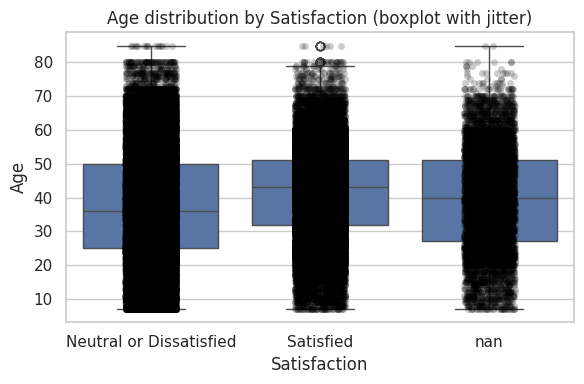


Contingency table: Satisfaction vs Gender
Gender                   Female   Male   nan
Satisfaction                                
Neutral or Dissatisfied   32754  31067  4643
Satisfied                 24537  24571  3534
nan                        4105   4073   596
Chi-square test (Satisfaction vs Gender): chi2=21.55, p-value=0.0002
Cramér's V (Satisfaction vs Gender): 0.009

Contingency table: Satisfaction vs Customer Type
Customer Type            First-time  Returning   nan
Satisfaction                                        
Neutral or Dissatisfied       15732      48018  4714
Satisfied                      5006      44075  3561
nan                            1446       6719   609
Chi-square test (Satisfaction vs Customer Type): chi2=3886.31, p-value=0.0000
Cramér's V (Satisfaction vs Customer Type): 0.122

Contingency table: Satisfaction vs Type of Travel
Type of Travel           Business  Personal   nan
Satisfaction                                     
Neutral or Dissatisfied   

<Figure size 600x600 with 0 Axes>

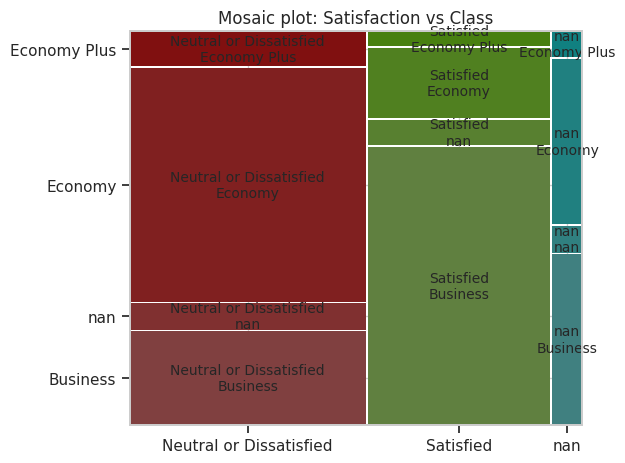


Contingency table: Satisfaction vs Type of Travel
Type of Travel           Business  Personal   nan
Satisfaction                                     
Neutral or Dissatisfied     32371     31426  4667
Satisfied                   45509      3524  3609
nan                          5661      2548   565
Odds ratio not computed because the table is not 2x2.


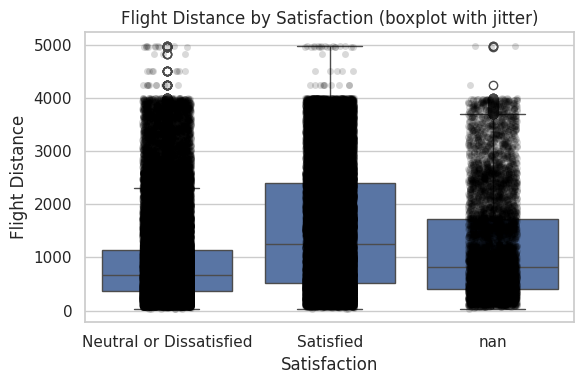

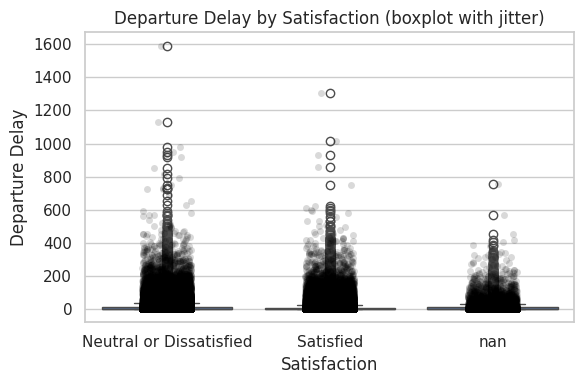

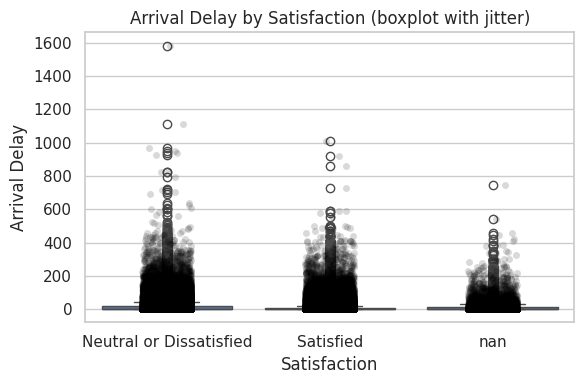

In [41]:
# C) EXPLORATORY DATA ANALYSIS (EDA)
# Uses the tidied df from part B (before modeling)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.mosaicplot import mosaic

sns.set(style="whitegrid")

df_eda = df.copy()
target_col = "Satisfaction"

# 1. Identify numeric and categorical columns

num_cols = df_eda.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df_eda.select_dtypes(include=["object", "category"]).columns.tolist()

# Remove ID from numeric columns if it exists
if "ID" in num_cols:
    num_cols.remove("ID")

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

# UNIVARIATE ANALYSIS

# 1) Descriptive statistics for numeric variables
if len(num_cols) > 0:
    desc_stats = df_eda[num_cols].describe().T
    print("\n=== Descriptive statistics for numeric variables ===")
    print(desc_stats)
else:
    print("\n[WARN] No numeric columns detected for descriptive statistics.")

# 2) Histograms for numeric variables
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_eda[col], kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# 3) Boxplots for numeric variables
for col in num_cols:
    plt.figure(figsize=(4, 5))
    sns.boxplot(y=df_eda[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# 4) Frequency tables and bar plots for categorical variables
for col in cat_cols:
    print(f"\n=== Frequency table for {col} ===")
    print(df_eda[col].value_counts(dropna=False))

    plt.figure(figsize=(6, 4))
    sns.countplot(x=df_eda[col])
    plt.title(f"Bar plot of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# BIVARIATE / MULTIVARIATE ANALYSIS
# A) Continuous variables: Correlation & Scatter

if len(num_cols) > 1:
    # Correlation matrix (Pearson)
    corr = df_eda[num_cols].corr()
    print("\n=== Correlation matrix (numeric variables) ===")
    print(corr)

    # Correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=False, cmap="coolwarm", square=True)
    plt.title("Correlation Heatmap of Numeric Variables")
    plt.tight_layout()
    plt.show()

# Example scatter plots for some important numeric pairs
pairs_to_plot = [
    ("Flight Distance", "Departure Delay"),
    ("Flight Distance", "Arrival Delay"),
    ("Departure Delay", "Arrival Delay")
]

for x_var, y_var in pairs_to_plot:
    if (x_var in df_eda.columns) and (y_var in df_eda.columns):
        plt.figure(figsize=(6, 5))
        sns.scatterplot(x=df_eda[x_var], y=df_eda[y_var], alpha=0.3)
        plt.title(f"Scatter plot: {x_var} vs {y_var}")
        plt.tight_layout()
        plt.show()

# Boxplot of Age by Satisfaction (example)
if ("Age" in df_eda.columns) and (target_col in df_eda.columns):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_eda[target_col], y=df_eda["Age"])
    sns.stripplot(x=df_eda[target_col], y=df_eda["Age"],
                  color="black", alpha=0.2, jitter=0.15)
    plt.title("Age distribution by Satisfaction (boxplot with jitter)")
    plt.tight_layout()
    plt.show()

# B) Categorical variables: Chi-square, Cramer's V, Odds Ratio

def cramers_v(confusion_matrix: pd.DataFrame) -> float:
    """Compute Cramér's V for a contingency table."""
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.values.sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

def odds_ratio_2x2(confusion_matrix: pd.DataFrame) -> float:
    """
    Compute Odds Ratio for a 2x2 table.
    Table format:
        [[a, b],
         [c, d]]
    Uses a small continuity correction to avoid division by zero.
    """
    if confusion_matrix.shape != (2, 2):
        raise ValueError("Odds ratio is defined only for 2x2 tables.")
    a, b, c, d = confusion_matrix.values.flatten()
    return (a * d) / ((b + 0.5) * (c + 0.5))

# 1) Loop over all categorical predictors vs target
if target_col in df_eda.columns:
    for col in cat_cols:
        if col == target_col:
            continue

        ct = pd.crosstab(df_eda[target_col], df_eda[col])
        print(f"\nContingency table: {target_col} vs {col}")
        print(ct)

        chi2, p, dof, exp = stats.chi2_contingency(ct)
        cv = cramers_v(ct)

        print(f"Chi-square test ({target_col} vs {col}): chi2={chi2:.2f}, p-value={p:.4f}")
        print(f"Cramér's V ({target_col} vs {col}): {cv:.3f}")

# 2) Mosaic plot example: Satisfaction vs Class
if ("Class" in df_eda.columns) and (target_col in df_eda.columns):
    df_mosaic = df_eda[[target_col, "Class"]].dropna()
    plt.figure(figsize=(6, 6))
    mosaic(df_mosaic, [target_col, "Class"])
    plt.title("Mosaic plot: Satisfaction vs Class")
    plt.tight_layout()
    plt.show()

# 3) Odds Ratio example: Satisfaction vs Type of Travel (if 2x2)
if ("Type of Travel" in df_eda.columns) and (target_col in df_eda.columns):
    ct_tt = pd.crosstab(df_eda[target_col], df_eda["Type of Travel"])
    print("\nContingency table: Satisfaction vs Type of Travel")
    print(ct_tt)

    if ct_tt.shape == (2, 2):
        or_value = odds_ratio_2x2(ct_tt)
        print(f"Odds Ratio (Satisfaction vs Type of Travel): {or_value:.3f}")
    else:
        print("Odds ratio not computed because the table is not 2x2.")

# EXTRA VISUALIZATIONS: Boxplots with jitter for several numeric vars by Satisfaction

for col in ["Flight Distance", "Departure Delay", "Arrival Delay"]:
    if (col in df_eda.columns) and (target_col in df_eda.columns):
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df_eda[target_col], y=df_eda[col])
        sns.stripplot(x=df_eda[target_col], y=df_eda[col],
                      color="black", alpha=0.15, jitter=0.15)
        plt.title(f"{col} by Satisfaction (boxplot with jitter)")
        plt.tight_layout()
        plt.show()


In [42]:
# D) CONFIRMATORY DATA ANALYSIS (CDA) - MODEL-BASED IMPUTATION

from scipy import stats
import pandas as pd
import numpy as np

# 1) Build CDA dataframe from CLEAN / IMPUTED data
#    Here we use MODEL-BASED imputed predictors: X_model_clean
df_cda = X_model_clean.copy()
df_cda["Satisfaction"] = y_clean

vars_for_cda = [
    "Age",
    "Flight Distance",
    "In-flight Service",
    "Departure Delay",
    "Arrival Delay",
    "Satisfaction",
    "Class"
]

df_cda = df_cda[vars_for_cda].copy()

# 2) Ensure numeric variables are numeric
numeric_candidates = ["Age", "Flight Distance", "In-flight Service",
                      "Departure Delay", "Arrival Delay"]

for col in numeric_candidates:
    df_cda[col] = pd.to_numeric(df_cda[col], errors="coerce")

# 3) Encode Satisfaction as binary 0/1 for group comparisons
df_cda["Satisfaction_bin"] = df_cda["Satisfaction"].map({
    "Satisfied": 1,
    "Neutral or Dissatisfied": 0
})

# ----------------------------------------
# Q1: Does Age differ by Satisfaction?
#    → independent t-test OR Mann–Whitney U
# ----------------------------------------
q1 = df_cda[["Age", "Satisfaction_bin"]].dropna()
age_sat = q1.loc[q1["Satisfaction_bin"] == 1, "Age"].astype(float)
age_unsat = q1.loc[q1["Satisfaction_bin"] == 0, "Age"].astype(float)

# Normality (Shapiro on subsample up to n=500 per group)
sh_sat = stats.shapiro(age_sat.sample(min(500, len(age_sat)), random_state=42))
sh_unsat = stats.shapiro(age_unsat.sample(min(500, len(age_unsat)), random_state=42))

print("\n[Q1] Normality Test (Age ~ Satisfaction)")
print("Satisfied p-value    :", sh_sat.pvalue)
print("Not satisfied p-value:", sh_unsat.pvalue)

if (sh_sat.pvalue > 0.05) and (sh_unsat.pvalue > 0.05):
    t_stat, p_val = stats.ttest_ind(age_sat, age_unsat, equal_var=False)
    print("\n[Q1] Independent t-test (Age by Satisfaction)")
    print(f"t = {t_stat:.3f}, p-value = {p_val:.5f}")
else:
    u_stat, p_val = stats.mannwhitneyu(age_sat, age_unsat, alternative="two-sided")
    print("\n[Q1] Mann–Whitney U (Age by Satisfaction)")
    print(f"U = {u_stat:.3f}, p-value = {p_val:.5f}")

# ----------------------------------------
# Q2: Does In-flight Service differ by Class?
#    → ANOVA + Kruskal–Wallis
# ----------------------------------------
q2 = df_cda[["In-flight Service", "Class"]].dropna()
q2["In-flight Service"] = q2["In-flight Service"].astype(float)

groups = [grp["In-flight Service"].values for _, grp in q2.groupby("Class")]

f_stat, p_anova = stats.f_oneway(*groups)
h_stat, p_kw = stats.kruskal(*groups)

print("\n[Q2] One-way ANOVA (In-flight Service by Class)")
print(f"F = {f_stat:.3f}, p-value = {p_anova:.5f}")

print("\n[Q2] Kruskal–Wallis (non-parametric alternative)")
print(f"H = {h_stat:.3f}, p-value = {p_kw:.5f}")

# ----------------------------------------
# Q3: Is Satisfaction independent of Class?
#    → Chi-square test
# ----------------------------------------
ct_class = pd.crosstab(df_cda["Satisfaction"], df_cda["Class"])
chi2, p_chi, dof, exp = stats.chi2_contingency(ct_class)

print("\n[Q3] Chi-square Test (Satisfaction vs Class)")
print("Chi2    =", chi2)
print("df      =", dof)
print("p-value =", p_chi)

# ----------------------------------------
# Q4: Are Departure Delay and Arrival Delay correlated?
#    → Pearson or Spearman
# ----------------------------------------
q4 = df_cda[["Departure Delay", "Arrival Delay"]].dropna()
dep = q4["Departure Delay"].astype(float)
arr = q4["Arrival Delay"].astype(float)

# Normality check on subsamples
sh_dep = stats.shapiro(dep.sample(min(500, len(dep)), random_state=42))
sh_arr = stats.shapiro(arr.sample(min(500, len(arr)), random_state=42))

if (sh_dep.pvalue > 0.05) and (sh_arr.pvalue > 0.05):
    r, p_corr = stats.pearsonr(dep, arr)
    print("\n[Q4] Pearson Correlation (Departure vs Arrival Delay)")
else:
    r, p_corr = stats.spearmanr(dep, arr)
    print("\n[Q4] Spearman Correlation (Departure vs Arrival Delay)")

print("r =", r, "p-value =", p_corr)



[Q1] Normality Test (Age ~ Satisfaction)
Satisfied p-value    : 1.682127518624171e-05
Not satisfied p-value: 9.191517232887889e-06

[Q1] Mann–Whitney U (Age by Satisfaction)
U = 2123456806.000, p-value = 0.00000

[Q2] One-way ANOVA (In-flight Service by Class)
F = 1180.549, p-value = 0.00000

[Q2] Kruskal–Wallis (non-parametric alternative)
H = 3847.661, p-value = 0.00000

[Q3] Chi-square Test (Satisfaction vs Class)
Chi2    = 28613.477129445957
df      = 6
p-value = 0.0

[Q4] Spearman Correlation (Departure vs Arrival Delay)
r = 0.7322406240128013 p-value = 0.0


Feature engineering complete. df_fe shape: (129880, 27)

Numeric columns for modeling: ['Age', 'Flight Distance', 'Departure Delay', 'Arrival Delay', 'Departure and Arrival Time Convenience', 'Ease of Online Booking', 'Check-in Service', 'Online Boarding', 'Gate Location', 'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness', 'Food and Drink', 'In-flight Service', 'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling', 'Total Delay', 'Long Haul', 'Avg Service Score', 'Is_Business_or_Upper']
Categorical columns for modeling: ['Gender', 'Customer Type', 'Type of Travel', 'Class']

X_prepared shape: (129880, 35)
Number of feature names: 35

Top 15 features by Mutual Information:
num__Online Boarding            0.197308
num__In-flight Wifi Service     0.151406
num__Avg Service Score          0.133165
cat__Class_Business             0.118665
num__Is_Business_or_Upper       0.103736
cat__Type of Travel_Personal    0.103500
cat__Class_Economy              0.0

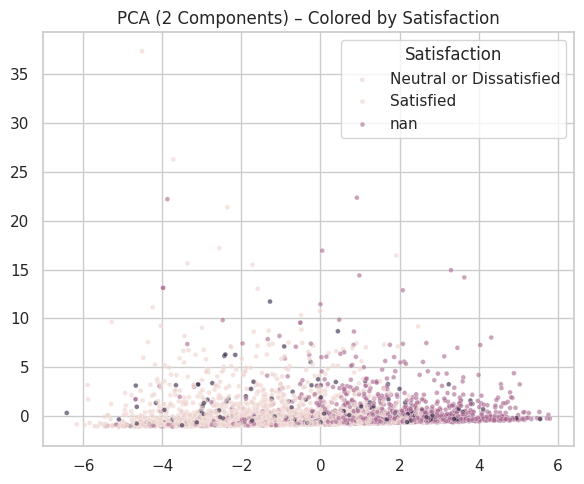


Explained variance ratio (PCA): [0.21657172 0.12988329]


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


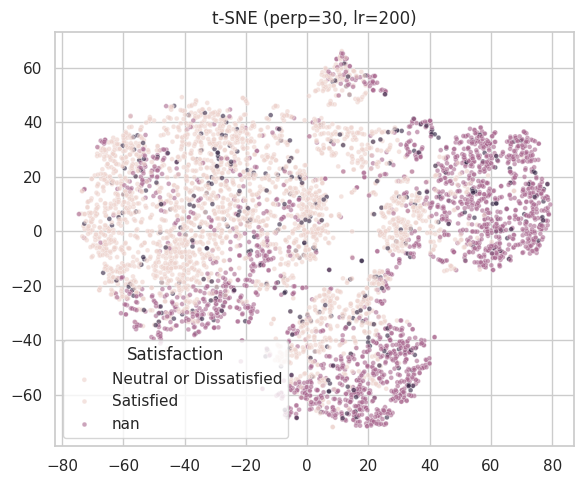

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


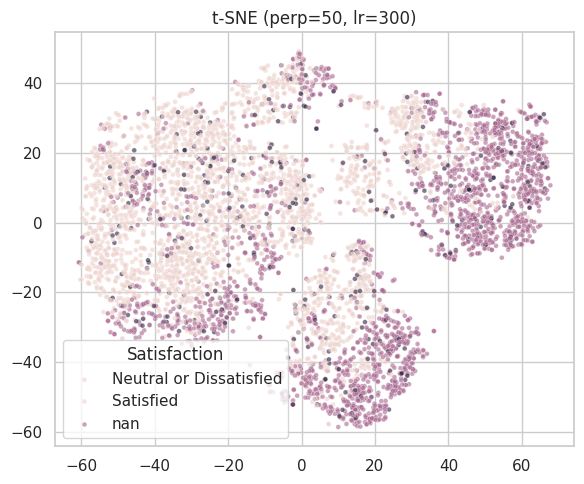

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


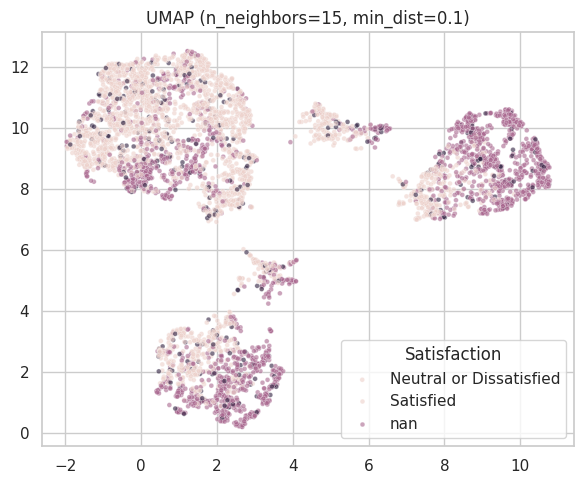

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


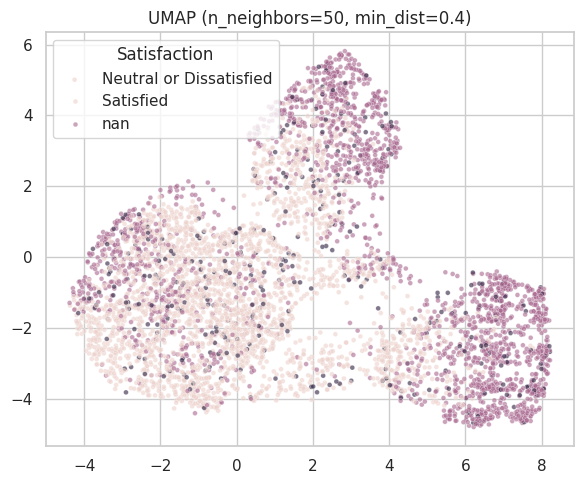

In [43]:
# =========================================
# E) FEATURE ENGINEERING & DIMENSION REDUCTION  (ERROR-FREE VERSION)
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.utils import resample

import umap

sns.set(style="whitegrid")
RANDOM_STATE = 42

# ------------------------------------------------
# E0) BUILD DATAFRAME FROM IMPUTED DATA
# ------------------------------------------------
df_fe = X_model_clean.copy()
df_fe["Satisfaction"] = y_clean

target_col = "Satisfaction"

# ------------------------------------------------
# E1) FEATURE ENGINEERING
# ------------------------------------------------

# 1) Total Delay
if ("Departure Delay" in df_fe.columns) and ("Arrival Delay" in df_fe.columns):
    df_fe["Total Delay"] = pd.to_numeric(df_fe["Departure Delay"], errors="coerce") + \
                           pd.to_numeric(df_fe["Arrival Delay"], errors="coerce")

# 2) Long-haul indicator
if "Flight Distance" in df_fe.columns:
    df_fe["Long Haul"] = (pd.to_numeric(df_fe["Flight Distance"], errors="coerce") > 1500).astype(int)

# 3) Average Service Score
service_cols = [
    "Departure and Arrival Time Convenience",
    "Ease of Online Booking",
    "Check-in Service",
    "Online Boarding",
    "Gate Location",
    "On-board Service",
    "Seat Comfort",
    "Leg Room Service",
    "Cleanliness",
    "Food and Drink",
    "In-flight Service",
    "In-flight Wifi Service",
    "In-flight Entertainment",
    "Baggage Handling"
]
service_cols = [c for c in service_cols if c in df_fe.columns]

if len(service_cols) > 0:
    df_fe[service_cols] = df_fe[service_cols].apply(pd.to_numeric, errors="coerce")
    df_fe["Avg Service Score"] = df_fe[service_cols].mean(axis=1)

# 4) Higher class indicator
if "Class" in df_fe.columns:
    df_fe["Is_Business_or_Upper"] = df_fe["Class"].isin(["Business", "Eco Plus"]).astype(int)

print("Feature engineering complete. df_fe shape:", df_fe.shape)

# ------------------------------------------------
# E2) PREPROCESSING: SCALE NUMERIC + ONE-HOT CATEGORICAL
# ------------------------------------------------
X = df_fe.drop(columns=[target_col])
y = df_fe[target_col]

# Identify numeric & categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Remove ID if present
if "ID" in num_cols:
    num_cols.remove("ID")

print("\nNumeric columns for modeling:", num_cols)
print("Categorical columns for modeling:", cat_cols)

# Encode target (binary or multi-class supported)
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Pipelines
num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols)
    ],
    remainder="drop"
)

X_prepared = preprocessor.fit_transform(X)

# ✅ ROBUST feature names (fixes your error)
feature_names = preprocessor.get_feature_names_out()

print("\nX_prepared shape:", X_prepared.shape)
print("Number of feature names:", len(feature_names))

# ------------------------------------------------
# E3) FEATURE SELECTION
#    A) Filter: Mutual Information
#    B) Embedded: L1 Logistic Regression
# ------------------------------------------------

# ---- A) Mutual Information (subsample + dense)
n_mi = min(5000, X_prepared.shape[0])
X_mi, y_mi = resample(
    X_prepared, y_enc,
    n_samples=n_mi,
    random_state=RANDOM_STATE,
    stratify=y_enc
)

X_mi_dense = X_mi.toarray() if hasattr(X_mi, "toarray") else X_mi

mi_scores = mutual_info_classif(
    X_mi_dense, y_mi,
    discrete_features=False,
    random_state=RANDOM_STATE
)

mi_series = pd.Series(mi_scores, index=feature_names).sort_values(ascending=False)

print("\nTop 15 features by Mutual Information:")
print(mi_series.head(15))

# ---- B) Embedded: L1 Logistic Regression
log_l1 = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=0.1,
    max_iter=4000,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
log_l1.fit(X_prepared, y_enc)

# ✅ FIX for multi-class: coef_ can be (n_classes, n_features)
coef_mat = log_l1.coef_  # shape: (n_classes, n_features) OR (1, n_features)
coef_importance = np.max(np.abs(coef_mat), axis=0)  # per-feature importance

l1_series = pd.Series(coef_importance, index=feature_names).sort_values(ascending=False)

print("\nTop 15 features by max(|L1 coef|) across classes:")
print(l1_series.head(15))

# Optional: show how many features are selected (non-zero in ANY class)
selected_mask = coef_importance != 0
print("\nNumber of selected features (non-zero in L1):", int(selected_mask.sum()))

# ------------------------------------------------
# E4) DIMENSION REDUCTION & VISUALIZATION
#     PCA (mandatory) + t-SNE + UMAP (tuning + comparison)
# ------------------------------------------------

# Subsample for speed
n_dr = min(5000, X_prepared.shape[0])
X_s, y_s = resample(
    X_prepared, y_enc,
    n_samples=n_dr,
    random_state=RANDOM_STATE,
    stratify=y_enc
)

X_s_dense = X_s.toarray() if hasattr(X_s, "toarray") else X_s

# ---- PCA (mandatory)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_s_dense)

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_s, s=12, alpha=0.6)
plt.title("PCA (2 Components) – Colored by Satisfaction")
plt.legend(title="Satisfaction", labels=le.inverse_transform(np.unique(y_s)))
plt.tight_layout()
plt.show()

print("\nExplained variance ratio (PCA):", pca.explained_variance_ratio_)

# ---- t-SNE (compare 2 settings)
tsne_settings = [
    {"perplexity": 30, "learning_rate": 200, "n_iter": 1000},
    {"perplexity": 50, "learning_rate": 300, "n_iter": 1000},
]

for cfg in tsne_settings:
    tsne = TSNE(
        n_components=2,
        perplexity=cfg["perplexity"],
        learning_rate=cfg["learning_rate"],
        n_iter=cfg["n_iter"],
        random_state=RANDOM_STATE
    )
    X_tsne = tsne.fit_transform(X_s_dense)

    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_s, s=12, alpha=0.6)
    plt.title(f"t-SNE (perp={cfg['perplexity']}, lr={cfg['learning_rate']})")
    plt.legend(title="Satisfaction", labels=le.inverse_transform(np.unique(y_s)))
    plt.tight_layout()
    plt.show()

# ---- UMAP (compare 2 settings)
umap_settings = [
    {"n_neighbors": 15, "min_dist": 0.1, "metric": "euclidean"},
    {"n_neighbors": 50, "min_dist": 0.4, "metric": "euclidean"},
]

for cfg in umap_settings:
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=cfg["n_neighbors"],
        min_dist=cfg["min_dist"],
        metric=cfg["metric"],
        random_state=RANDOM_STATE
    )
    X_um = reducer.fit_transform(X_s_dense)

    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=X_um[:, 0], y=X_um[:, 1], hue=y_s, s=12, alpha=0.6)
    plt.title(f"UMAP (n_neighbors={cfg['n_neighbors']}, min_dist={cfg['min_dist']})")
    plt.legend(title="Satisfaction", labels=le.inverse_transform(np.unique(y_s)))
    plt.tight_layout()
    plt.show()


In [46]:
# =========================================
# F) STATISTICAL MODELING (PREDICTION / CLASSIFICATION)
#     (MODEL-BASED IMPUTATION PIPELINE, LEAKAGE-FREE)
# =========================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, cohen_kappa_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42

# -------------------------------------------------------
# F0) INPUTS expected from Part E
#   X_prepared : transformed features (sparse/dense)
#   y_enc      : encoded target (0..K-1)
#   le         : LabelEncoder fitted on original Satisfaction labels (optional)
# -------------------------------------------------------
X_all = X_prepared
y_all = y_enc

# -------------------------------------------------------
# F0.1) Remove rare classes (<2) to avoid stratify/CV issues
# -------------------------------------------------------
y_series = pd.Series(y_all)
class_counts = y_series.value_counts()
print("\nClass counts BEFORE filtering:")
print(class_counts)

rare_classes = class_counts[class_counts < 2].index.tolist()

if len(rare_classes) > 0:
    print("\nRemoving rare classes (count < 2):", rare_classes)
    mask = ~y_series.isin(rare_classes)
    X_model = X_all[mask.values]          # works for numpy/sparse
    y_model = y_series[mask].to_numpy()
else:
    X_model = X_all
    y_model = y_all

print("\nClass counts AFTER filtering:")
print(pd.Series(y_model).value_counts())

n_classes = len(np.unique(y_model))
is_binary = (n_classes == 2)

# -------------------------------------------------------
# F1) Train/Test split (stratified)
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_model
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nTrain class distribution (proportions):")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

# -------------------------------------------------------
# Helpers
# -------------------------------------------------------
def macro_specificity(y_true, y_pred):
    """
    Compute macro-averaged specificity for multi-class.
    For each class k:
      specificity_k = TN_k / (TN_k + FP_k)
    Return mean across classes.
    """
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for k in range(cm.shape[0]):
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        denom = (tn + fp)
        specs.append(tn / denom if denom > 0 else np.nan)
    return float(np.nanmean(specs))

def roc_auc_robust(model, X_test, y_test, is_binary):
    if not hasattr(model, "predict_proba"):
        return np.nan
    proba = model.predict_proba(X_test)
    try:
        if is_binary:
            return float(roc_auc_score(y_test, proba[:, 1]))
        else:
            return float(roc_auc_score(y_test, proba, multi_class="ovr"))
    except Exception:
        return np.nan

def eval_clf(name, model, X_test, y_test, is_binary, label_encoder=None):
    y_pred = model.predict(X_test)
    auc = roc_auc_robust(model, X_test, y_test, is_binary)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)   # macro sensitivity
    f1   = f1_score(y_test, y_pred, average="macro", zero_division=0)
    kappa = cohen_kappa_score(y_test, y_pred)
    spec = macro_specificity(y_test, y_pred)

    print(f"\n==================== {name} ====================")
    print("Accuracy            :", acc)
    print("Precision (macro)   :", prec)
    print("Recall/Sensitivity  :", rec)
    print("Specificity (macro) :", spec)
    print("F1-score (macro)    :", f1)
    print("Cohen's Kappa       :", kappa)
    print("ROC-AUC             :", auc)
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Pretty label names if LabelEncoder is available
    if label_encoder is not None:
        target_names = [str(x) for x in label_encoder.inverse_transform(np.unique(y_test))]
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))
    else:
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision_macro": prec,
        "Recall_macro": rec,
        "Specificity_macro": spec,
        "F1_macro": f1,
        "Kappa": kappa,
        "AUC": auc
    }

# CV setup (keep small & safe)
min_class = pd.Series(y_train).value_counts().min()
n_splits = max(2, min(5, int(min_class)))  # cannot exceed smallest class count
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
print(f"\nUsing StratifiedKFold with n_splits = {n_splits}")

results = []

# -------------------------------------------------------
# F2) Baseline Logistic Regression (L2) — NO SMOTE
# -------------------------------------------------------
baseline = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=3000
)
baseline.fit(X_train, y_train)
results.append(eval_clf("Baseline Logistic (L2, no SMOTE)", baseline, X_test, y_test, is_binary, le if "le" in globals() else None))

# -------------------------------------------------------
# F3) Regularized Models (Ridge / Lasso / Elastic Net) — NO SMOTE
#     GridSearchCV on TRAIN only
# -------------------------------------------------------
# Ridge (L2)
ridge = LogisticRegression(
    penalty="l2",
    solver="saga",
    max_iter=4000
)
grid_ridge = GridSearchCV(
    ridge,
    param_grid={"C": [0.1, 1, 10]},
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_
print("\nBest Ridge params:", grid_ridge.best_params_, "Best CV f1_macro:", grid_ridge.best_score_)
results.append(eval_clf(f"Ridge Logistic (no SMOTE, C={grid_ridge.best_params_['C']})", best_ridge, X_test, y_test, is_binary, le if "le" in globals() else None))

# Lasso (L1)
lasso = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=4000
)
grid_lasso = GridSearchCV(
    lasso,
    param_grid={"C": [0.05, 0.1, 1]},
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_
print("\nBest Lasso params:", grid_lasso.best_params_, "Best CV f1_macro:", grid_lasso.best_score_)
results.append(eval_clf(f"Lasso Logistic (no SMOTE, C={grid_lasso.best_params_['C']})", best_lasso, X_test, y_test, is_binary, le if "le" in globals() else None))

# Elastic Net
enet = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    max_iter=6000
)
grid_enet = GridSearchCV(
    enet,
    param_grid={"C": [0.05, 0.1, 1], "l1_ratio": [0.3, 0.7]},
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)
grid_enet.fit(X_train, y_train)
best_enet = grid_enet.best_estimator_
print("\nBest Elastic Net params:", grid_enet.best_params_, "Best CV f1_macro:", grid_enet.best_score_)
results.append(eval_clf(
    f"Elastic Net Logistic (no SMOTE, C={grid_enet.best_params_['C']}, l1_ratio={grid_enet.best_params_['l1_ratio']})",
    best_enet, X_test, y_test, is_binary, le if "le" in globals() else None
))

# -------------------------------------------------------
# F4) Imbalanced Handling — SMOTE INSIDE CV (leakage-free)
#     Compare Elastic Net + SMOTE
# -------------------------------------------------------
pipe_smote_enet = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(
        penalty="elasticnet",
        solver="saga",
        max_iter=6000
    ))
])

grid_smote_enet = GridSearchCV(
    pipe_smote_enet,
    param_grid={"clf__C": [0.05, 0.1, 1], "clf__l1_ratio": [0.3, 0.7]},
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)
grid_smote_enet.fit(X_train, y_train)

best_smote_enet = grid_smote_enet.best_estimator_
print("\nBest Elastic Net + SMOTE params:", grid_smote_enet.best_params_, "Best CV f1_macro:", grid_smote_enet.best_score_)

results.append(eval_clf(
    f"Elastic Net + SMOTE (C={grid_smote_enet.best_params_['clf__C']}, l1_ratio={grid_smote_enet.best_params_['clf__l1_ratio']})",
    best_smote_enet, X_test, y_test, is_binary, le if "le" in globals() else None
))

# -------------------------------------------------------
# F5) Summary table
# -------------------------------------------------------
results_df = pd.DataFrame(results).sort_values(by="F1_macro", ascending=False)
print("\n==================== MODEL COMPARISON (sorted by F1_macro) ====================")
print(results_df.to_string(index=False))



Class counts BEFORE filtering:
0    68464
1    52642
2     8774
Name: count, dtype: int64

Class counts AFTER filtering:
0    68464
1    52642
2     8774
Name: count, dtype: int64

Train shape: (97410, 35)
Test shape : (32470, 35)

Train class distribution (proportions):
0    0.527133
1    0.405307
2    0.067560
Name: proportion, dtype: float64

Using StratifiedKFold with n_splits = 5

==================== Baseline Logistic (L2, no SMOTE) ====================
Accuracy            : 0.8084385586695411
Precision (macro)   : 0.5384345264648748
Recall/Sensitivity  : 0.5748916956618726
Specificity (macro) : 0.8768419149965285
F1-score (macro)    : 0.5558915598997176
Cohen's Kappa       : 0.6342161089864784
ROC-AUC             : 0.7602517948053112

Confusion Matrix:
 [[15370  1746     0]
 [ 2281 10880     0]
 [ 1268   925     0]]

Classification Report:
                         precision    recall  f1-score   support

Neutral or Dissatisfied       0.81      0.90      0.85     17116
         

In [47]:
# =========================================
# G) MODEL EVALUATION & CONCLUSION (STATISTICAL MODELS)
#     - Compare: Base vs Ridge/Lasso/ElasticNet vs Balanced (SMOTE)
#     - Compare feature sets: Full vs Feature Selection vs Dimension Reduction
#     - Metrics: Sensitivity, Specificity, Kappa, ROC-AUC, F1 (macro)
#     - Coefficient interpretation (odds ratios) + basic assumption checks
# =========================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, cohen_kappa_score
)

from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import TruncatedSVD   # works well with sparse matrices

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------------------------------------
# G0) Inputs expected from Part E
# -------------------------------------------------------
X_full = X_prepared          # full feature matrix from preprocessing
y = y_enc                    # encoded target
fn = feature_names           # feature names from preprocessor.get_feature_names_out()

label_encoder = le if "le" in globals() else None

# Identify binary vs multiclass for AUC computation
n_classes = len(np.unique(y))
is_binary = (n_classes == 2)

# -------------------------------------------------------
# G1) Train/Test Split (single hold-out for final comparison)
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

# Cross-validation (small + stable)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# -------------------------------------------------------
# G2) Metrics helpers
# -------------------------------------------------------
def macro_specificity(y_true, y_pred):
    """
    Macro-averaged specificity for multi-class.
    For each class k: TN_k / (TN_k + FP_k)
    """
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for k in range(cm.shape[0]):
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn_ = cm[k, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn_)
        denom = (tn + fp)
        specs.append(tn / denom if denom > 0 else np.nan)
    return float(np.nanmean(specs))

def roc_auc_robust(model, X_eval, y_eval, is_binary):
    if not hasattr(model, "predict_proba"):
        return np.nan
    proba = model.predict_proba(X_eval)
    try:
        if is_binary:
            return float(roc_auc_score(y_eval, proba[:, 1]))
        else:
            return float(roc_auc_score(y_eval, proba, multi_class="ovr"))
    except Exception:
        return np.nan

def evaluate_model(name, model, X_eval, y_eval, feature_set_name, label_encoder=None, verbose=False):
    y_pred = model.predict(X_eval)
    auc = roc_auc_robust(model, X_eval, y_eval, is_binary)

    acc   = accuracy_score(y_eval, y_pred)
    prec  = precision_score(y_eval, y_pred, average="macro", zero_division=0)
    rec   = recall_score(y_eval, y_pred, average="macro", zero_division=0)   # macro sensitivity
    f1m   = f1_score(y_eval, y_pred, average="macro", zero_division=0)
    kappa = cohen_kappa_score(y_eval, y_pred)
    spec  = macro_specificity(y_eval, y_pred)

    if verbose:
        print(f"\n=== {name} [{feature_set_name}] ===")
        print("Accuracy:", acc)
        print("Precision_macro:", prec)
        print("Recall_macro (Sensitivity):", rec)
        print("Specificity_macro:", spec)
        print("F1_macro:", f1m)
        print("Kappa:", kappa)
        print("ROC-AUC:", auc)
        print("Confusion Matrix:\n", confusion_matrix(y_eval, y_pred))
        print(classification_report(y_eval, y_pred, zero_division=0))

    return {
        "Feature_Set": feature_set_name,
        "Model": name,
        "Accuracy": acc,
        "Precision_macro": prec,
        "Sensitivity_macro": rec,
        "Specificity_macro": spec,
        "F1_macro": f1m,
        "Kappa": kappa,
        "AUC": auc
    }

# -------------------------------------------------------
# G3) Build alternative feature sets
#     A) Full features (already X_train/X_test)
#     B) Feature selection (SelectKBest using Mutual Information)
#     C) Dimension reduction (TruncatedSVD for sparse)
# -------------------------------------------------------

# --- B) Feature selection: keep top-k informative features
k = min(80, X_train.shape[1])  # adjust 50/80/100 depending on size; 80 is a good default
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_train_fs = selector.fit_transform(X_train, y_train)
X_test_fs  = selector.transform(X_test)

selected_idx = selector.get_support(indices=True)
fn_fs = np.array(fn)[selected_idx]

# --- C) Dimension reduction: TruncatedSVD (PCA-like for sparse)
n_comp = min(30, X_train.shape[1] - 1)  # 20–50 typical; keep it moderate
svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
X_train_dr = svd.fit_transform(X_train)
X_test_dr  = svd.transform(X_test)

# -------------------------------------------------------
# G4) Define statistical models to compare
#     - Baseline Logistic (L2)
#     - Ridge (L2), Lasso (L1), Elastic Net (L1+L2) with small tuning
#     - Balanced versions using SMOTE (for imbalanced classification)
# -------------------------------------------------------

def tune_logreg(base_model, param_grid, Xtr, ytr):
    """
    Tune hyperparameters using CV on training data only.
    """
    grid = GridSearchCV(
        base_model,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=1
    )
    grid.fit(Xtr, ytr)
    return grid.best_estimator_, grid.best_params_, grid.best_score_

def fit_models_for_feature_set(Xtr, ytr, Xte, yte, feature_set_name):
    rows = []

    # 1) Baseline (L2)
    base = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=2000)
    base.fit(Xtr, ytr)
    rows.append(evaluate_model("Baseline Logistic (L2)", base, Xte, yte, feature_set_name, label_encoder))

    # 2) Ridge (L2) tuned
    ridge_base = LogisticRegression(penalty="l2", solver="saga", max_iter=2000, tol=1e-3)
    ridge_best, ridge_params, ridge_cv = tune_logreg(ridge_base, {"C": [0.1, 1]}, Xtr, ytr)
    rows.append(evaluate_model(f"Ridge (L2) C={ridge_params['C']}", ridge_best, Xte, yte, feature_set_name, label_encoder))

    # 3) Lasso (L1) tuned
    lasso_base = LogisticRegression(penalty="l1", solver="saga", max_iter=2500, tol=1e-3)
    lasso_best, lasso_params, lasso_cv = tune_logreg(lasso_base, {"C": [0.1, 1]}, Xtr, ytr)
    rows.append(evaluate_model(f"Lasso (L1) C={lasso_params['C']}", lasso_best, Xte, yte, feature_set_name, label_encoder))

    # 4) Elastic Net tuned
    enet_base = LogisticRegression(penalty="elasticnet", solver="saga", max_iter=3000, tol=1e-3)
    enet_best, enet_params, enet_cv = tune_logreg(enet_base, {"C": [0.1, 1], "l1_ratio": [0.3, 0.7]}, Xtr, ytr)
    rows.append(evaluate_model(
        f"Elastic Net C={enet_params['C']}, l1_ratio={enet_params['l1_ratio']}",
        enet_best, Xte, yte, feature_set_name, label_encoder
    ))

    # 5) Balanced model (SMOTE + Elastic Net) — leakage-safe inside CV
    pipe = ImbPipeline(steps=[
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(penalty="elasticnet", solver="saga", max_iter=3000, tol=1e-3))
    ])
    grid_sm = GridSearchCV(
        pipe,
        param_grid={"clf__C": [0.1, 1], "clf__l1_ratio": [0.3, 0.7]},
        scoring="f1_macro",
        cv=cv,
        n_jobs=1
    )
    grid_sm.fit(Xtr, ytr)
    sm_best = grid_sm.best_estimator_
    rows.append(evaluate_model(
        f"Elastic Net + SMOTE (tuned) {grid_sm.best_params_}",
        sm_best, Xte, yte, feature_set_name, label_encoder
    ))

    return rows

# -------------------------------------------------------
# G5) Run comparisons for each feature set
# -------------------------------------------------------
all_rows = []

# A) Full features
all_rows += fit_models_for_feature_set(X_train, y_train, X_test, y_test, "Full Features")

# B) Feature selection
all_rows += fit_models_for_feature_set(X_train_fs, y_train, X_test_fs, y_test, f"Feature Selection (Top {k} MI)")

# C) Dimension reduction
all_rows += fit_models_for_feature_set(X_train_dr, y_train, X_test_dr, y_test, f"Dimension Reduction (SVD {n_comp})")

results_g = pd.DataFrame(all_rows)

# Sort by F1_macro (most important for imbalanced classification)
results_g_sorted = results_g.sort_values(by=["F1_macro", "AUC"], ascending=False)

print("\n==================== G) MODEL COMPARISON (sorted by F1_macro then AUC) ====================")
print(results_g_sorted.to_string(index=False))

# -------------------------------------------------------
# G6) Identify the best model overall
# -------------------------------------------------------
best_row = results_g_sorted.iloc[0]
print("\n==================== BEST MODEL (by F1_macro then AUC) ====================")
print(best_row)

# -------------------------------------------------------
# G7) Coefficient interpretation (odds ratios) for the best *non-SMOTE* linear model
#     - For interpretability, prefer a non-pipeline logistic model (not the SMOTE pipeline)
#     - We'll pick the best among the non-SMOTE models within the same best feature set
# -------------------------------------------------------
best_feature_set = best_row["Feature_Set"]

subset = results_g_sorted[
    (results_g_sorted["Feature_Set"] == best_feature_set) &
    (~results_g_sorted["Model"].str.contains("SMOTE"))
].copy()

best_linear = subset.iloc[0]["Model"]
print("\nBest interpretable (non-SMOTE) model within best feature set:", best_linear)

# Refit that model to extract coefficients
def refit_for_coefficients(feature_set_name, model_label):
    # Select the matching X matrices
    if feature_set_name == "Full Features":
        Xtr, Xte, feat_names = X_train, X_test, np.array(fn)
    elif feature_set_name.startswith("Feature Selection"):
        Xtr, Xte, feat_names = X_train_fs, X_test_fs, fn_fs
    else:  # Dimension Reduction
        Xtr, Xte, feat_names = X_train_dr, X_test_dr, np.array([f"SVD_{i+1}" for i in range(n_comp)])

    # Decide which penalty based on label
    if "Baseline" in model_label or "Ridge" in model_label:
        # L2
        if "Ridge" in model_label:
            C_val = float(model_label.split("C=")[1])
            clf = LogisticRegression(penalty="l2", solver="saga", C=C_val, max_iter=2000, tol=1e-3)
        else:
            clf = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=2000)
    elif "Lasso" in model_label:
        C_val = float(model_label.split("C=")[1])
        clf = LogisticRegression(penalty="l1", solver="saga", C=C_val, max_iter=2500, tol=1e-3)
    else:
        # Elastic Net
        # model_label format: "Elastic Net C=..., l1_ratio=..."
        parts = model_label.replace("Elastic Net ", "").split(",")
        C_val = float(parts[0].split("=")[1])
        l1_val = float(parts[1].split("=")[1])
        clf = LogisticRegression(penalty="elasticnet", solver="saga", C=C_val, l1_ratio=l1_val, max_iter=3000, tol=1e-3)

    clf.fit(Xtr, y_train)
    return clf, feat_names

clf_coef, feat_names_used = refit_for_coefficients(best_feature_set, best_linear)

if hasattr(clf_coef, "coef_"):
    # For binary: shape (1, n_features)
    # For multiclass: shape (n_classes, n_features) -> show max abs effect
    coef = clf_coef.coef_
    if coef.ndim == 2 and coef.shape[0] > 1:
        coef_effect = np.max(np.abs(coef), axis=0)
    else:
        coef_effect = coef.flatten()

    coef_df = pd.DataFrame({
        "Feature": feat_names_used,
        "Coef": coef_effect,
        "Odds_Ratio": np.exp(coef_effect)
    }).sort_values(by="Coef", ascending=False)

    print("\n==================== TOP POSITIVE COEFFICIENTS (increase satisfaction odds) ====================")
    print(coef_df.head(15).to_string(index=False))

    print("\n==================== TOP NEGATIVE COEFFICIENTS (decrease satisfaction odds) ====================")
    print(coef_df.tail(15).to_string(index=False))

# -------------------------------------------------------
# G8) Assumption checks / validity notes (lightweight, report-friendly)
# -------------------------------------------------------
print("\n==================== ASSUMPTION / VALIDITY NOTES (for report) ====================")
print("- Logistic regression assumes independent observations and correct model specification.")
print("- Multicollinearity is reduced by regularization (Ridge/Lasso/Elastic Net).")
print("- Linearity in the log-odds is an assumption for continuous predictors;")
print("  regularization and feature engineering help, but you should interpret coefficients cautiously.")
print("- Using SMOTE improves minority-class recall, but coefficients from SMOTE models are less interpretable.")



==================== G) MODEL COMPARISON (sorted by F1_macro then AUC) ====================
                  Feature_Set                                                             Model  Accuracy  Precision_macro  Sensitivity_macro  Specificity_macro  F1_macro    Kappa      AUC
                Full Features Elastic Net + SMOTE (tuned) {'clf__C': 0.1, 'clf__l1_ratio': 0.7}  0.696982         0.582259           0.553960           0.855335  0.556500 0.498114 0.758589
Feature Selection (Top 35 MI) Elastic Net + SMOTE (tuned) {'clf__C': 0.1, 'clf__l1_ratio': 0.7}  0.696982         0.582259           0.553960           0.855335  0.556500 0.498114 0.758589
 Dimension Reduction (SVD 30) Elastic Net + SMOTE (tuned) {'clf__C': 0.1, 'clf__l1_ratio': 0.3}  0.696797         0.582047           0.553590           0.855240  0.556251 0.497823 0.758560
Feature Selection (Top 35 MI)                                                  Lasso (L1) C=0.1  0.808747         0.538631           0.575122          